In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_cafe_sales.csv")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])
df["Month_Num"] = df["Transaction Date"].dt.month
df["Month_Name"] = df["Transaction Date"].dt.month_name()
df["DayOfWeek"] = df["Transaction Date"].dt.day_name()

print("Dataset Dimensions:", df.shape)
print("\n--- DESCRIPTIVE STATISTICS ---")
print(df[["Quantity", "Price Per Unit", "Total Spent"]].describe().round(2))

Dataset Dimensions: (10000, 11)

--- DESCRIPTIVE STATISTICS ---
       Quantity  Price Per Unit  Total Spent
count   9977.00         9946.00      9977.00
mean       3.02            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.00            5.00        25.00


In [2]:

item_performance = df[df["Item"] != "Unknown"].groupby("Item").agg(
    Revenue=("Total Spent", "sum"),
    Units_Sold=("Quantity", "sum"),
    Avg_Ticket=("Total Spent", "mean"),
    Orders=("Transaction ID", "count")
).sort_values(by="Revenue", ascending=False)

print("--- ITEM REVENUE & VOLUME BREAKDOWN ---")
print(item_performance)

--- ITEM REVENUE & VOLUME BREAKDOWN ---
          Revenue  Units_Sold  Avg_Ticket  Orders
Item                                             
Salad     17345.0      3469.0   15.135253    1148
Sandwich  13716.0      3429.0   12.170364    1131
Smoothie  13344.0      3336.0   12.197441    1096
Juice     10515.0      3505.0    9.002568    1171
Cake      10404.0      3468.0    9.142355    1139
Coffee     7072.0      3536.0    6.096552    1165
Tea        4960.5      3307.0    4.559283    1089
Cookie     3232.0      3232.0    2.965138    1092


In [3]:
monthly_trend = df.groupby(["Month_Num", "Month_Name"])["Total Spent"].sum().reset_index()
print("Top 3 & Bottom 3 Revenue Months:")
print(monthly_trend.sort_values(by="Total Spent", ascending=False).iloc[[0, 1, 2, -3, -2, -1]])

print("\n--- PAYMENT METHOD DISTRIBUTION ---")
print(df[df["Payment Method"] != "Unknown"]["Payment Method"].value_counts(normalize=True) * 100)

Top 3 & Bottom 3 Revenue Months:
   Month_Num Month_Name  Total Spent
5          6       June       7793.5
2          3      March       7620.5
9         10    October       7606.0
6          7       July       7241.5
8          9  September       7196.5
1          2   February       7020.0

--- PAYMENT METHOD DISTRIBUTION ---
Payment Method
Digital Wallet    33.582527
Credit Card       33.318675
Cash              33.098798
Name: proportion, dtype: float64


/tmp/ipykernel_4216/1681343530.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=item_performance["Revenue"].values, y=item_performance.index, ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_4216/1681343530.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Quantity", data=df, ax=axes[1, 0], palette="crest")


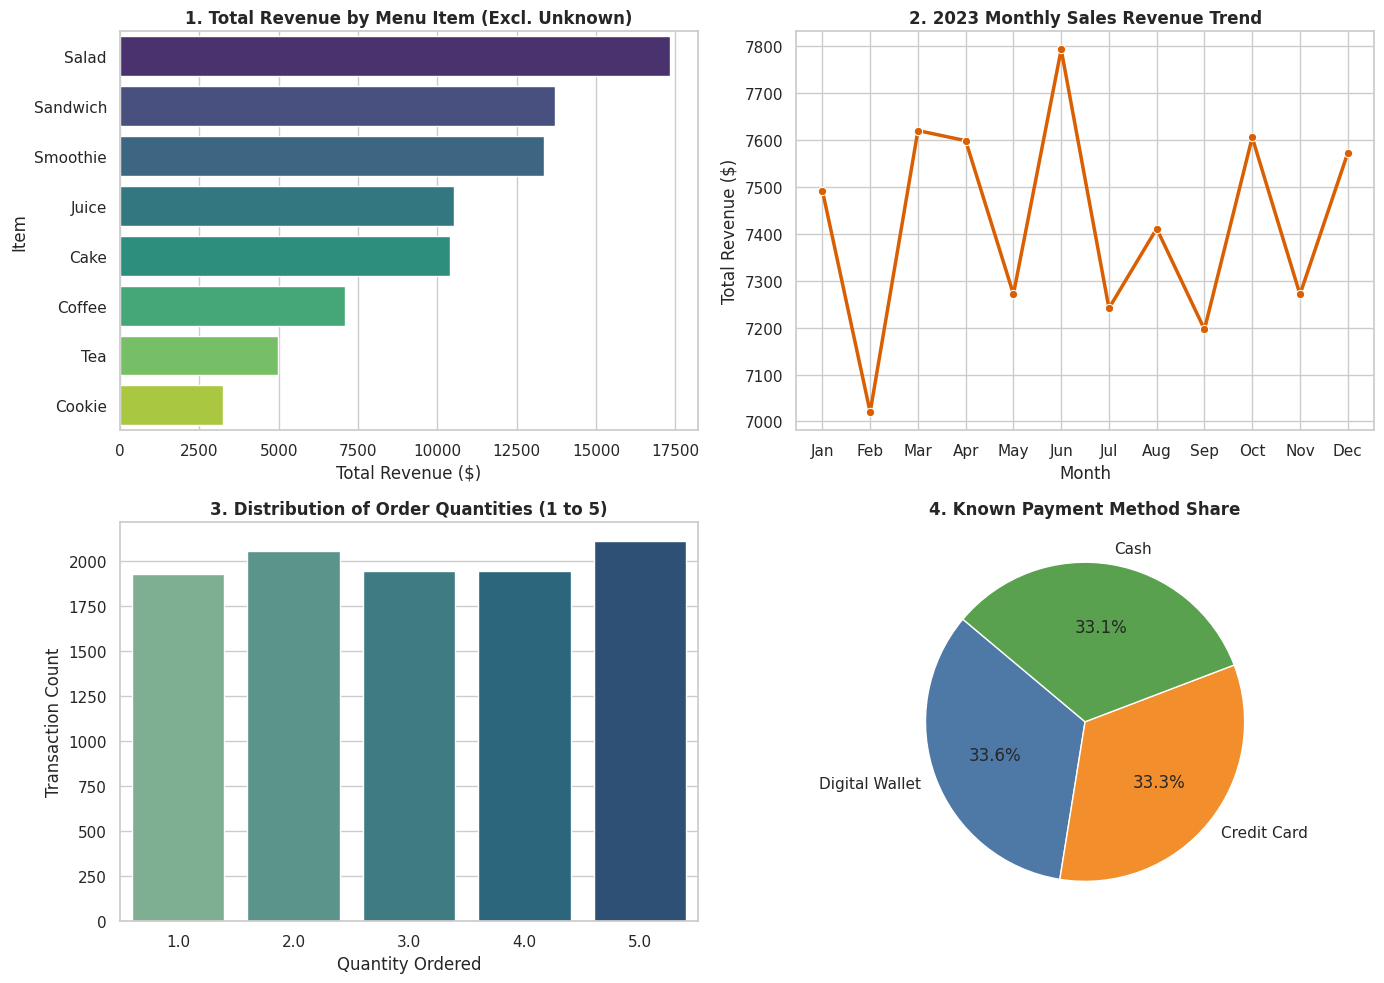

Dashboard generated and saved as eda_summary_charts.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x=item_performance["Revenue"].values, y=item_performance.index, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("1. Total Revenue by Menu Item (Excl. Unknown)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Total Revenue ($)")
axes[0, 0].set_ylabel("Item")

sns.lineplot(x="Month_Num", y="Total Spent", data=monthly_trend, marker="o", color="#d95f02", linewidth=2.5, ax=axes[0, 1])
axes[0, 1].set_title("2. 2023 Monthly Sales Revenue Trend", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Total Revenue ($)")
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

sns.countplot(x="Quantity", data=df, ax=axes[1, 0], palette="crest")
axes[1, 0].set_title("3. Distribution of Order Quantities (1 to 5)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Quantity Ordered")
axes[1, 0].set_ylabel("Transaction Count")

known_pm = df[df["Payment Method"] != "Unknown"]["Payment Method"].value_counts()
axes[1, 1].pie(known_pm.values, labels=known_pm.index, autopct="%1.1f%%", colors=["#4e79a7", "#f28e2b", "#59a14f"], startangle=140)
axes[1, 1].set_title("4. Known Payment Method Share", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("eda_summary_charts.png", dpi=300)
plt.show()
print("Dashboard generated and saved as eda_summary_charts.png")